# Modèle de Heston

On considère l'actif risqué $(S_t)_{t \in [0,T]}$ modélisé par l'EDS suivante 
\begin{equation*}
    \begin{cases}
    \operatorname{d}\! S_t = r S_t \operatorname{d}\! t + \sqrt{v_t} S_t \operatorname{d}\! W^S_t, & S_0 > 0 \\
    \operatorname{d}\! v_t = (a - \lambda v_t) \operatorname{d}\! t + \sigma \sqrt{v_t} \operatorname{d}\! W^v_t, & v_0 > 0
    \end{cases}
\end{equation*}
où les processus $(W^S_t)_{t \in [0,T]}$ et $(W^v_t)_{t \in [0,T]}$ sont des mouvements Browniens standards réels corrélés avec un coefficient $\rho \in [-1,1]$ c'est à dire 
\begin{equation*}
    \forall t \in [0,T], \quad \operatorname{cor}(W^S_t, W^v_t) = \rho
\end{equation*}

Les paramètres $a > 0$, $\lambda > 0$ et $\sigma > 0$ sont supposés vérifiés la relation suivante $2 a > \sigma^2$. Sous cette condition, le processus $(v_t)_{t \ge 0}$ reste strictement positif (avec probabilité 1). 

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme() 
from numpy.random import default_rng
rng = default_rng()
import pandas as pd

In [2]:
def monte_carlo(sample, proba=0.95):
    mean = np.mean(sample)
    var = np.var(sample, ddof=1)
    quantile = stats.norm.ppf(1 - (1-proba)/2)
    ci_size = quantile * np.sqrt(var / sample.size)    
    result = { "mean": mean, "var": var, "lower": mean - ci_size, "upper": mean + ci_size }
    return result

## Classe `Heston`

### Question: partie théorique

1. Ecrire le coupe $(W_t^S, W_t^v)_{t \in [0,T]}$ comme combinaison linéaire de deux mouvements Browniens indépendants $(W_t)_{t \in [0,T]}$ et $(B_t)_{t \in [0,T]}$. On dit aussi que $(W_t, B_t)_{t \in [0,T]}$ est un mouvement Brownien bidimensionnel.

2. Ecrire $(\bar S_{t_k}, \bar v_{t_k})_{k=0,\dots,N}$ le schéma d'Euler défini aux instants $t_k = kh = \frac{k T}{N}$.

3. Montrer que $\mathbf{P}\big(\bar v_{t_{k+1}} < 0 | \bar v_{t_k} > 0\big) > 0$.  
Qu'en déduire quand à l'utilisation de ce schéma en pratique ? Proposer une correction possible.

### Question: schéma d'Euler

Ecrire une classe `Heston` sur le modèle de la classe `Black-Scholes` de la feuille précédente.  

Implémenter le schéma d'Euler (avec correction) dans une méthode `paths_euler` qui prend comme argument des accroissements du mouvement Brownien bidimensionnel $(W_t, B_t)_{t \in [0,T]}$ aux instants $t_k = kh = \frac{k T}{N}$. 

In [35]:
class Heston:
    def __init__(self, x0, r, sigma, T, kappa, theta, xi, rho):
        self.x0 = x0
        self.r = r
        self.sigma = sigma
        self.T = T
        self.kappa = kappa
        self.theta = theta
        self.xi = xi
        self.rho = rho
    
    def paths_euler(self, dW, dZ):
        N = dW.shape[0]
        S = np.zeros(N)
        v = np.zeros(N)
        S[0] = self.x0
        v[0] = self.sigma**2
        for i in range(0, N-1):
            v[i+1] = v[i] + self.kappa * (self.theta - v[i]) * self.T/N + self.xi * np.sqrt(np.abs(v[i])) * dZ[i]
            S[i+1] = S[i] * np.exp((self.r - 0.5 * v[i]) * self.T/N + np.sqrt(np.abs(v[i])) * dW[i])
        return S, v

### Question: visualisation de trajectoires

On considère les paramètres $S_0 = 100$, $v_0 = 0.1$, $r = 0.05$, $a = 0.1$, $\lambda = 0.1$, $\sigma=0.1$, $\rho=0.3$ et la maturité $T = 1$.

Tracer 20 trajectoires du spot et de la volatilité obtenues avec un schéma d'Euler de pas $h = \frac{1}{N}$ et $N = 50$.

Prix exact de l'option : 22.2035


Text(0.5, 0, 'Temps')

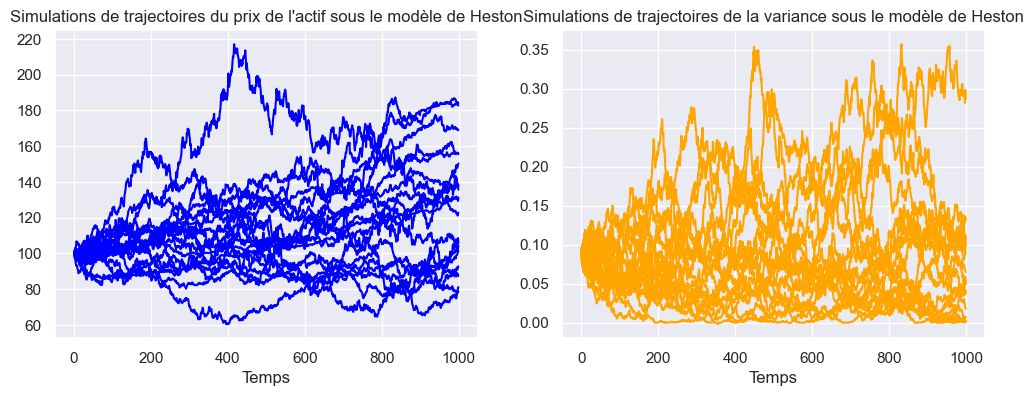

In [36]:
X = Heston(x0=100, r=0.2, sigma=0.3, T=1, kappa=2, theta=0.04, xi=0.5, rho=0.3)
def bs_call(X : Heston, K):
    d1 = (np.log(X.x0/K) + (X.r + 0.5 * X.sigma**2) * X.T) / (X.sigma * np.sqrt(X.T))
    d2 = d1 - X.sigma * np.sqrt(X.T)
    return X.x0 * stats.norm.cdf(d1) - K * np.exp(-X.r * X.T) * stats.norm.cdf(d2)
exact_price = bs_call(X, K=100)
print(f'Prix exact de l\'option : {exact_price:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

N = 1000
M = 20
dW = rng.normal(0, np.sqrt(X.T/N), size=(N, M))
dZ = rng.normal(0, np.sqrt(X.T/N), size=(N, M))
for i in range(M):
    S, v = X.paths_euler(dW[:, i], dZ[:, i])
    ax[0].plot(S, color='blue')
    ax[1].plot(v, color='orange')
ax[0].set_title('Simulations de trajectoires du prix de l\'actif sous le modèle de Heston')
ax[0].set_xlabel('Temps')
ax[1].set_title('Simulations de trajectoires de la variance sous le modèle de Heston')
ax[1].set_xlabel('Temps')

### Question: pricing

On fixe $M = 20\,000$ le nombre de simulations.
- Calculer le prix d'un call de strike $K = 100$.  
- Donner le prix (et l'intervalle de confiance) en fonction de $N$.
- Tracer le résultat.

In [38]:
M = 20000
dW = rng.normal(0, np.sqrt(X.T/N), size=(N, M))
dZ = rng.normal(0, np.sqrt(X.T/N), size=(N, M))

payoff_paths = np.zeros((M))
for i in range(M):
    S, v = X.paths_euler(dW[:, i], dZ[:, i])
    payoff_paths[i] = np.maximum(S[-1] - 100, 0)

price_estimate = np.exp(-X.r * X.T) * np.mean(payoff_paths)
print(f'Prix estimé de l\'option par Monte Carlo : {price_estimate:.4f}')

Prix estimé de l'option par Monte Carlo : 20.6463


## Pricing par préconditionnement

Soit $\varphi$ une fonction de payoff classique et $P_{BS}(x, r, s) = \mathbf{E}\big[e^{-rT} \varphi \big(x e^{(r-\frac{s^2}{2}) T + s B_T} \big) \big]$ le prix dans un modèle de Black-Scholes de valeur initiale $x > 0$, de taux $r$ et de volatilité constante $s$. On note $\mathcal{F}_t = \sigma(W_s, 0 \le s \le t)$. 

### Question: partie théorique

1. Montrer qu'il existe $x_0$ variable aléatoire $\mathcal{F}_T$-mesurable telle que

$$
    \mathbf{E}\big[ e^{-rT} \varphi(S_T)|\mathcal{F}_T \big] = P_{BS}\Bigg(x_0, r, \sqrt{\frac{1}{T} \int_0^T (1-\rho^2) v_t \operatorname{d}\! t}\Bigg),
$$

(faire le cas $\rho = 0$ pour commencer).

3. En notant $Z$ la variable aléatoire de loi $\mathbf{E} \big[e^{-rT} \varphi(S_T)|\mathcal{F}_T \big]$, montrer que

$$
    \operatorname{var}(Z) \le \operatorname{var}\big(e^{-rT} \varphi(S_T)\big)
$$

5. En déduire un estimateur de Monte Carlo _a priori_ plus efficace que l'estimateur naïf pour le calcul de $\mathbf{E}\big[e^{-rT} \varphi(S_T)\big]$.

### Question: implémentation

Calculer le prix du call de strike $K=100$ en utilisant ce préconditionnement (il faut utiliser la formule fermée de Black-Scholes pour calculer $P_{BS}$). 

Comparer les résultats en fonction de $N$ avec les prix obtenus précédemment sans précondtionnement. Faire un tracé.

## Création d'un projet 

Créer un répertoire qui va contenir les fichiers suivants: 
- `product.json` un fichier au format json qui contient les paramètres du modèle
- `heston.py` un script python qui contient une fonction `euler_heston` qui simule des trajectoires (en pytorch par exemple)
- `run.py` un script python qui lit le fichier `product.json` et qui appelle la fonction `euler_heston` du fichier `heston.py`

On peut ajouter des options en ligne de commande pour par exemple pourvoir executer: 
```{sh}
python3 run.py product.json --n_times 100 --n_paths 8192 --device mps
```

On utilisera les modules `json` et `argparse` (les installer et lire la documentation).

## Schéma d'Euler et Milstein sur le log-spot (opt.)

On considère maintenant $X_t = \log S_t$.

### Question: partie théorique

1. Ecrire l'EDS satisfaite par le couple $(X_t, v_t)$ ainsi que son schéma d'Euler $(\bar X_{t_k}, \bar v_{t_k})_{k \in \{0,\dots, N\}}$ de pas $h = \frac{T}{N}$ défini aux instants $t_k = k h$, $k \in \{0,\dots,N\}$.

2. Montrer que $\mathbf{P}\big(\bar v_{t_{k+1}} < 0 | \bar v_{t_k} > 0\big) > 0$. Qu'en déduire quand à l'utilisation de ce schéma en pratique ?

3. On considère le processus $z_t = e^{\lambda t} v_t$. Montrer que le schéma de Milstein de $(z_t)_{t \in [0,T]}$ défini aux instants $t_k = k h$ s'écrit

$$
    \tilde z_{t_{k+1}} = \tilde z_{t_k} + \Big(a - \frac{\sigma^2}{4}\Big) e^{\lambda t_k} h + \sigma e^{\frac{\lambda}{2} t_k} \sqrt{\tilde z_{t_k}} G_{k+1} + \frac{\sigma^2}{4} e^{\lambda t_k} G_{k+1}^2,
$$

avec $(G_k)_{k \ge 1}$ une suite _i.i.d._ à déterminer.
Comment apparaît le terme $-\frac{\sigma^2}{4} e^{\lambda t_k} h$ et que représente $G_{k+1}$ ? 
Rappeler brièvement les propriétés (convergence forte et convergence faible) de ce schéma de discrétisation.

5. Montrer que $\tilde v_{t_k} = e^{-\lambda t_k} \tilde z_{t_k}$ vérifie pour tout $k \in \{0, \dots, N\}$, $\mathbf{P}\big(\tilde v_{t_k} > 0\big) = 1$.

### Question: implémentation

## Schéma alternatif pour la volatilité (opt.)

### Question: partie théorique 

1. Montrer que $y_t = \sqrt{v_t}$ vérifie

$$
   \operatorname{d}\! y_t = \Big( \frac{a - \sigma^2/4}{2 y_t} - \frac{\lambda}{2} y_t \Big) \operatorname{d}\! t +
   \frac{\sigma}{2} \operatorname{d}\! W_t, \quad y_0 = \sqrt{v_0}.
$$

2. En déduire que pour tout $0 \le s < t$,

$$
    y_t = e^{-\frac{\lambda}{2}(t-s)} y_s + \int_s^t \frac{a - \sigma^2/4}{2 y_u} e^{-\frac{\lambda}{2}(t-u)}
   \operatorname{d}\! u + \int_s^t e^{-\frac{\lambda}{2}(t-u)} \frac{\sigma}{2} \operatorname{d}\! W_u.
$$

Quelle est la loi de $\int_s^t e^{-\frac{\lambda}{2}(t-u)} \frac{\sigma}{2} \operatorname{d}\! W_u$ ?

5. En déduire le schéma de discrétisation "implicite" $\big(Y_{t_k}\big)_{k=0,\dots,N}$ de $(y_t)_{t \ge 0}$ de la forme

$$
    \forall k \ge 0, \quad Y_{t_{k+1}} = e^{-\frac{\lambda}{2} h} Y_{t_k} + \frac{a-\sigma^2/4}{Y_{t_{k+1}}}\Big(\frac{1-e^{-\frac{\lambda}{2}h}}{\lambda}\Big) + \frac{\sigma}{2} U_{k+1}^{\lambda, h},
$$

où $h = t_{k+1} - t_k = \frac{T}{N}$, $t_0 = 0$ et $\big(U_{n}^{\lambda, h}\big)_{n \ge 1}$ est une suite de v.a. _i.i.d._ à déterminer.
Pour tout $k \in \{1,\dots,N\}$, écrire $Y_{t_{k}}$ comme solution d'un polynôme du second degré que vous expliciterez.

7. En déduire un schéma de discrétisation pour $(v_t)_{t \ge 0}$. Quel est l'avantage de ce schéma par rapport au schéma d'Euler ?

### Question: implémentation

## Simulation exacte (opt.)

Dans cette dernière partie, on veut simuler de façon exacte le processus $(v_t)_{t \in [0,T]}$ lorsque la condition $\frac{4 a}{\sigma^2} \in \mathbf{N}$ est satisfaite. 

### Question: partie théorique

On admet que la transformée de Laplace de $v_t$ vérifie

$$
    \mathbf{E}\big[ e^{-\theta v_t} | v_0 \big] = F(t, v_0) = (2 \theta L(t) + 1)^{-\frac{2 a}{\sigma^2}} 
    \exp\Big(-\frac{\theta L(t)\chi(t, v_0)}{2 \theta L(t) + 1}\Big),
$$

avec $L(t) = \frac{\sigma^2}{4 \lambda}(1-e^{-\lambda t})$ et $\chi(t, v_0) = \frac{4 v_0 \lambda e^{-\lambda t}}{\sigma^2(1-e^{-\lambda t})}$.

1. Déterminer la transformée de Laplace de $w_t = \frac{v_t}{L(t)}$.

2. Calculer la transformée de Laplace de $N^2$ où $N \sim \mathcal{N}(m, 1)$, $m \in \mathbf{R}$.

3. En déduire la simulation exacte de $v_T$ puis d'un vecteur $(v_{t_1}, v_{t_2}, \dots, v_{t_N})$ aux instants $t_k = kh$.

### Question: implémentation

Ecrire un code pour faire de la simulation exacte du vecteur $(v_{t_1}, v_{t_2}, \dots, v_{t_N})$